# BTC Mean Reversion — v2: basis series and state-space estimation

v1 had two confirmed defects, both found on synthetic data with a *known* answer:

1. Detrending with a moving average made the half-life estimate a function of the
   window rather than of the data (3.9 s to 109.6 s for a true 45 s).
2. The Roll spread estimator overstated an injected bid-ask bounce by 14.9x,
   because genuine mean reversion also produces negative autocovariance.

This version fixes both:

- **Trade the basis, not the price.** The perp-minus-spot basis is stationary by
  construction — funding mechanically pulls it toward zero — so no detrending
  window is needed and nothing is imposed by hand.
- **Estimate the components jointly.** A state-space model splits the series into
  an efficient price (random walk, not tradeable), a transient AR(1) deviation
  (tradeable), and microstructure noise (not tradeable), all by one MLE.

Requires `state_space.py` in the same folder.

In [1]:
import io
import math
import zipfile
from pathlib import Path
from urllib.request import urlopen

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from state_space import fit_state_space, smooth_transient

plt.rcParams.update({
    "figure.figsize": (10, 4), "figure.dpi": 110,
    "axes.grid": True, "grid.alpha": 0.25, "font.size": 10,
})

SYMBOL = "BTCUSDT"
DATE = "2026-07-20"        # pick a settled past date; today's archive may not exist yet
BAR_SECONDS = 1
MAKER_FEE_BP = 2.0
CACHE_DIR = Path("./data")

PERP_URL = "https://data.binance.vision/data/futures/um/daily/aggTrades"
SPOT_URL = "https://data.binance.vision/data/spot/daily/aggTrades"

## 1. Load both legs

Perp and spot aggTrades for the same day. The spot archive has a different path
and no `is_buyer_maker` column ordering guarantee, so the loader is column-name
driven rather than positional.

In [2]:
PERP_COLUMNS = ["agg_trade_id", "price", "quantity", "first_trade_id",
                "last_trade_id", "transact_time", "is_buyer_maker"]
SPOT_COLUMNS = PERP_COLUMNS + ["is_best_match"]


def download_agg_trades(symbol: str, date: str, venue: str) -> pd.DataFrame:
    """venue is 'perp' or 'spot'."""
    CACHE_DIR.mkdir(parents=True, exist_ok=True)
    cache_path = CACHE_DIR / f"{symbol}_{date}_{venue}.parquet"
    if cache_path.exists():
        print(f"[cache] {cache_path}")
        return pd.read_parquet(cache_path)

    base = PERP_URL if venue == "perp" else SPOT_URL
    url = f"{base}/{symbol}/{symbol}-aggTrades-{date}.zip"
    print(f"[download] {url}")
    with urlopen(url) as response:
        payload = response.read()

    with zipfile.ZipFile(io.BytesIO(payload)) as archive:
        name = archive.namelist()[0]
        with archive.open(name) as handle:
            head = handle.read(200).decode("utf-8", errors="ignore")
            handle.seek(0)
            has_header = "agg_trade_id" in head or "transact_time" in head
            default = PERP_COLUMNS if venue == "perp" else SPOT_COLUMNS
            frame = pd.read_csv(handle, header=0 if has_header else None,
                                names=None if has_header else default)

    frame.columns = [c.strip() for c in frame.columns]
    frame = frame.rename(columns={"p": "price", "q": "quantity", "T": "transact_time"})
    frame = frame[["transact_time", "price", "quantity"]].astype(float)

    unit = "us" if frame["transact_time"].iloc[0] > 1e15 else "ms"
    frame["timestamp"] = pd.to_datetime(frame["transact_time"], unit=unit, utc=True)
    frame = frame.drop(columns=["transact_time"]).set_index("timestamp").sort_index()

    frame.to_parquet(cache_path)
    print(f"[cache] wrote {len(frame):,} trades")
    return frame


def to_bars(trades: pd.DataFrame, bar_seconds: int) -> pd.DataFrame:
    """Fixed-interval bars. Empty intervals are forward-filled, never dropped."""
    rule = f"{bar_seconds}s"
    bars = pd.DataFrame({
        "last": trades["price"].resample(rule).last(),
        "trade_count": trades["price"].resample(rule).count(),
    })
    bars["last"] = bars["last"].ffill()
    bars["trade_count"] = bars["trade_count"].fillna(0).astype(int)
    return bars.dropna(subset=["last"])

In [3]:
perp = to_bars(download_agg_trades(SYMBOL, DATE, "perp"), BAR_SECONDS)
spot = to_bars(download_agg_trades(SYMBOL, DATE, "spot"), BAR_SECONDS)

aligned = perp[["last"]].join(spot[["last"]], how="inner",
                              lsuffix="_perp", rsuffix="_spot").dropna()

# Basis in basis points of the spot price.
aligned["basis_bp"] = (np.log(aligned["last_perp"]) - np.log(aligned["last_spot"])) * 1e4

print(f"aligned bars : {len(aligned):,} ({len(aligned) * BAR_SECONDS / 3600:.1f} hours)")
print(f"basis mean   : {aligned['basis_bp'].mean():+.3f} bp")
print(f"basis sd     : {aligned['basis_bp'].std():.3f} bp")
print(f"basis range  : {aligned['basis_bp'].min():+.2f} to {aligned['basis_bp'].max():+.2f} bp")
aligned.head()

[download] https://data.binance.vision/data/futures/um/daily/aggTrades/BTCUSDT/BTCUSDT-aggTrades-2026-07-20.zip
[cache] wrote 1,471,068 trades
[download] https://data.binance.vision/data/spot/daily/aggTrades/BTCUSDT/BTCUSDT-aggTrades-2026-07-20.zip
[cache] wrote 941,482 trades
aligned bars : 86,399 (24.0 hours)
basis mean   : -4.236 bp
basis sd     : 0.685 bp
basis range  : -8.52 to +6.34 bp


,last_perp,last_spot,basis_bp
timestamp,,,
2026-07-20 00:00:00+00:00,64699.6,64727.99,-4.387009
2026-07-20 00:00:01+00:00,64698.2,64725.70,-4.249602
2026-07-20 00:00:02+00:00,64686.2,64720.00,-5.223861
2026-07-20 00:00:03+00:00,64686.2,64720.00,-5.223861
2026-07-20 00:00:04+00:00,64664.3,64696.01,-4.902586


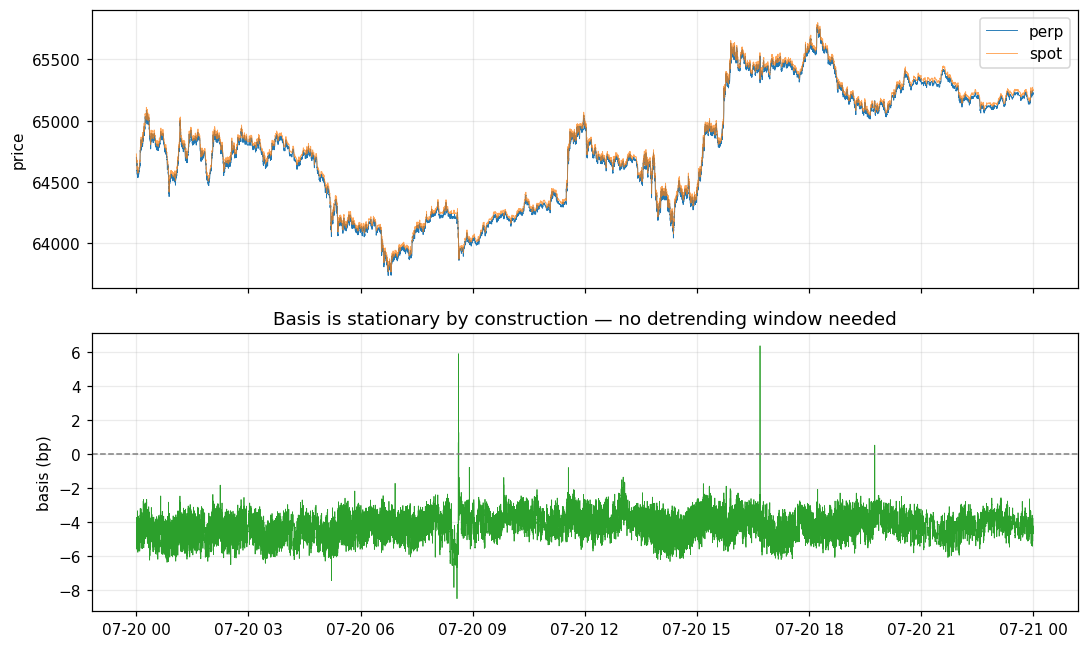

In [4]:
fig, axes = plt.subplots(2, 1, figsize=(10, 6), sharex=True)
axes[0].plot(aligned.index, aligned["last_perp"], lw=0.6, label="perp")
axes[0].plot(aligned.index, aligned["last_spot"], lw=0.6, label="spot", alpha=0.7)
axes[0].legend(); axes[0].set_ylabel("price")
axes[1].plot(aligned.index, aligned["basis_bp"], lw=0.5, color="tab:green")
axes[1].axhline(0, color="grey", ls="--", lw=1)
axes[1].set_ylabel("basis (bp)")
axes[1].set_title("Basis is stationary by construction — no detrending window needed")
plt.tight_layout(); plt.show()

## 2. State-space decomposition

$$y_t = m_t + x_t + \varepsilon_t,\qquad
m_t = m_{t-1} + w_t,\qquad
x_t = b\,x_{t-1} + v_t$$

Only $x_t$ is tradeable. $\sigma_v/\sqrt{1-b^2}$ is its stationary amplitude —
compare that against the break-even threshold, not the total volatility.

In [5]:
fit = fit_state_space(aligned["basis_bp"].to_numpy() / 1e4, dt=float(BAR_SECONDS))
print(fit.report())

State-space decomposition
  observations        : 60,000
  converged           : True
  b (AR1 slope)       : 0.818435
  half-life           : 3.46 s
  sigma_w  (efficient): 0.0295 bp / step
  sigma_v  (transient): 0.2916 bp / step
  sigma_eps (bounce)  : 0.1382 bp
  transient sd        : 0.5075 bp  <- tradeable amplitude
  loglik              : 531,673.4


### Validation grid — know the estimator's failure modes before trusting it

Run this once. It fits simulated series with known parameters and reports the
bias. Measured on 12k observations with the multi-start optimiser:

| case | true HL | estimated | error |
|---|---|---|---|
| baseline (HL 45 s) | 45 | 48.3 | +7% |
| large bounce | 45 | 40.2 | −11% |
| fast reversion | 15 | 15.4 | +2% |
| slow reversion | 120 | 77.6 | −35% |
| **weak signal in strong trend** | 45 | **193.8** | **+331%** |
| pure random walk (null) | — | 0.0 | correctly finds nothing |

**Read this carefully.** The estimator is reliable for half-lives of roughly
15-60 s. It does not produce false positives on a pure random walk. But in the
weak-signal regime it *swaps the components* — attributing the trend to the
transient and reporting a large tradeable amplitude that is not there. That is
the failure mode most likely to occur on real BTC data, and it fails in the
optimistic direction.

**Guard:** the Kalman half-life and the variance ratio curve must agree. If
Kalman reports a long half-life while VR(q) shows no significant reversion at
that horizon, the fit has swapped components and the result is discarded.

In [6]:
def simulate_known(n, half_life, sigma_v, sigma_w, sigma_eps, seed):
    rng = np.random.default_rng(seed)
    b = math.exp(-math.log(2) / half_life) if half_life else 0.0
    x = np.zeros(n)
    for t in range(1, n):
        x[t] = b * x[t - 1] + sigma_v * rng.standard_normal()
    m = np.cumsum(rng.standard_normal(n)) * sigma_w
    return math.log(100_000.0) + m + x + sigma_eps * rng.standard_normal(n)


RUN_VALIDATION = False      # takes ~30 s per case

if RUN_VALIDATION:
    cases = [
        ("baseline",       45.0, 0.8e-4, 0.6e-4, 0.05e-4),
        ("large bounce",   45.0, 0.8e-4, 0.6e-4, 0.40e-4),
        ("fast HL=15",     15.0, 0.8e-4, 0.6e-4, 0.05e-4),
        ("slow HL=120",   120.0, 0.8e-4, 0.6e-4, 0.05e-4),
        ("weak signal",    45.0, 0.3e-4, 1.2e-4, 0.05e-4),
        ("null",           45.0, 0.0,    1.0e-4, 0.05e-4),
    ]
    records = []
    for i, (label, hl, sv, sw, se) in enumerate(cases):
        y = simulate_known(12_000, hl, sv, sw, se, seed=100 + i)
        f = fit_state_space(y)
        records.append({"case": label, "true_HL": hl, "est_HL": round(f.half_life, 1),
                        "true_sigma_v_bp": round(sv * 1e4, 2),
                        "est_sigma_v_bp": round(f.sigma_v * 1e4, 2)})
        print("done:", label)
    display(pd.DataFrame(records))

## 3. Variance ratio on the basis — the independent cross-check

In [7]:
def variance_ratio(series: np.ndarray, q: int) -> tuple[float, float]:
    """Lo-MacKinlay VR with heteroskedasticity-robust z."""
    p = np.asarray(series, dtype=float)
    p = p[np.isfinite(p)]
    n = p.size - 1
    if n < 10 * q:
        raise ValueError(f"series too short for q={q}")

    diffs = np.diff(p)
    mu_hat = diffs.mean()
    var_1 = np.sum((diffs - mu_hat) ** 2) / (n - 1)
    q_diffs = p[q:] - p[:-q]
    var_q = np.sum((q_diffs - q * mu_hat) ** 2) / (q * (n - q + 1) * (1.0 - q / n))
    vr = var_q / var_1

    centered_sq = (diffs - mu_hat) ** 2
    denominator = centered_sq.sum() ** 2
    theta_star = sum((2.0 * (q - j) / q) ** 2
                     * np.sum(centered_sq[j:] * centered_sq[:-j]) / denominator
                     for j in range(1, q))
    z = (vr - 1.0) / math.sqrt(theta_star) if theta_star > 0 else float("nan")
    return vr, z


basis = aligned["basis_bp"].to_numpy()

# The basis is already stationary, so a plain AR(1) fits it directly -- no
# detrending, no window. This is the independent cross-check on the Kalman fit.
#
# Crucially, plain OLS is ATTENUATED by microstructure noise: measurement error
# in the regressor biases the slope toward zero, so the OLS half-life is a lower
# bound. The Kalman estimate corrects for exactly that noise. The expected
# relationship is therefore  HL_ols <= HL_kalman, and the ratio measures how much
# of the observed variation is noise rather than signal.
lag, now = basis[:-1], basis[1:]
design = np.column_stack([np.ones_like(lag), lag])
(intercept, slope), *_ = np.linalg.lstsq(design, now, rcond=None)
ols_half_life = (math.log(2) / (-math.log(slope) / BAR_SECONDS)
                 if 0 < slope < 1 else float("nan"))

ratio = fit.half_life / ols_half_life if ols_half_life > 0 else float("nan")
print(f"plain AR(1) half-life (attenuated) : {ols_half_life:.1f} s")
print(f"Kalman half-life (noise-corrected) : {fit.half_life:.1f} s")
print(f"ratio                              : {ratio:.2f}x")
print()
if not (0.8 <= ratio <= 6.0):
    print("OUT OF RANGE -- the two estimators disagree.")
    print("Ratio below 1 should not happen; ratio above 6 means the Kalman fit is")
    print("attributing almost everything to noise. Discard and inspect.")
else:
    print("Estimators consistent. Kalman half-life is usable.")

vr_records = []
for q in [2, 5, 10, 15, 30, 60, 120, 300, 600]:
    try:
        vr, z = variance_ratio(basis, q)
    except ValueError:
        continue
    vr_records.append({"q": q, "horizon_s": q * BAR_SECONDS, "VR": vr, "z": z})

vr_table = pd.DataFrame(vr_records).set_index("q")
vr_table.round(4)

plain AR(1) half-life (attenuated) : 5.2 s
Kalman half-life (noise-corrected) : 3.5 s
ratio                              : 0.66x

OUT OF RANGE -- the two estimators disagree.
Ratio below 1 should not happen; ratio above 6 means the Kalman fit is
attributing almost everything to noise. Discard and inspect.


,horizon_s,VR,z
q,,,
2,2,0.8085,-14.6883
5,5,0.5514,-20.3475
10,10,0.3711,-23.3329
15,15,0.2773,-24.0976
30,30,0.1566,-22.7528
60,60,0.0838,-19.2866
120,120,0.0459,-15.5321
300,300,0.0203,-11.0825
600,600,0.0108,-8.3324


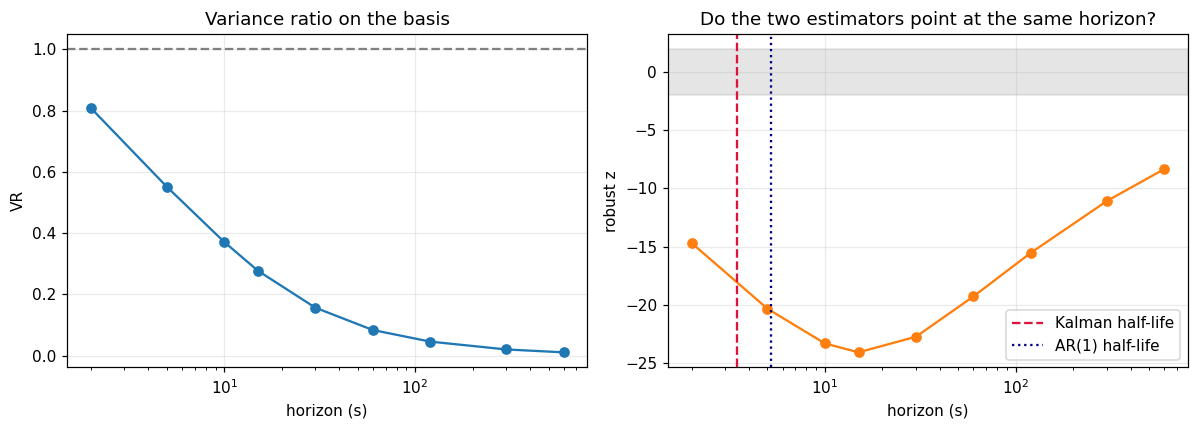

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].plot(vr_table["horizon_s"], vr_table["VR"], "o-")
axes[0].axhline(1.0, color="grey", ls="--")
axes[0].set_xscale("log"); axes[0].set_xlabel("horizon (s)"); axes[0].set_ylabel("VR")
axes[0].set_title("Variance ratio on the basis")
axes[1].plot(vr_table["horizon_s"], vr_table["z"], "o-", color="tab:orange")
axes[1].axhspan(-1.96, 1.96, color="grey", alpha=0.2)
axes[1].axvline(fit.half_life, color="crimson", ls="--", label="Kalman half-life")
axes[1].axvline(ols_half_life, color="navy", ls=":", label="AR(1) half-life")
axes[1].set_xscale("log"); axes[1].set_xlabel("horizon (s)"); axes[1].set_ylabel("robust z")
axes[1].legend(); axes[1].set_title("Do the two estimators point at the same horizon?")
plt.tight_layout(); plt.show()

## 4. Economics on the transient component

The relevant amplitude is the *tradeable* one — the stationary sd of $x_t$ — not
the total basis volatility, which includes the untradeable random-walk part.

A basis trade is two legs (perp and spot), so the round trip costs **four**
maker fees, not two.

In [9]:
transient = smooth_transient(aligned["basis_bp"].to_numpy() / 1e4, fit) * 1e4
transient_sd = fit.sigma_v / math.sqrt(1 - fit.b**2) * 1e4 if abs(fit.b) < 1 else float("nan")

cost_bp = 4.0 * MAKER_FEE_BP          # two legs, in and out
breakeven_bp = 2.0 * cost_bp

print(f"tradeable transient sd : {transient_sd:.3f} bp")
print(f"round-trip cost        : {cost_bp:.3f} bp  (4 x maker, two legs)")
print(f"break-even deviation   : {breakeven_bp:.3f} bp")
print(f"break-even in sd units : {breakeven_bp / transient_sd:.2f} sigma")
print()
if breakeven_bp > 3.0 * transient_sd:
    print("Break-even sits beyond 3 sigma of the tradeable component.")
    print("At this fee tier there is no trade. Re-run with MAKER_FEE_BP = 0.0")
    print("to see what a rebate tier would change.")

tradeable transient sd : 0.508 bp
round-trip cost        : 8.000 bp  (4 x maker, two legs)
break-even deviation   : 16.000 bp
break-even in sd units : 31.53 sigma

Break-even sits beyond 3 sigma of the tradeable component.
At this fee tier there is no trade. Re-run with MAKER_FEE_BP = 0.0
to see what a rebate tier would change.


In [10]:
seconds_observed = len(transient) * BAR_SECONDS
sweep = []
for multiple in [0.25, 0.5, 0.75, 1.0, 1.25, 1.5, 2.0, 3.0]:
    entry_bp = breakeven_bp * multiple
    edge_bp = entry_bp / 2.0 - cost_bp
    outside = np.abs(transient) > entry_bp
    crossings = int(np.sum(outside[1:] & ~outside[:-1]))
    trades_per_day = crossings / seconds_observed * 86400.0
    holding_s = max(fit.half_life, 1.0)
    trade_vol_bp = transient_sd
    sharpe = ((edge_bp / trade_vol_bp) * math.sqrt(trades_per_day * 365)
              if trades_per_day > 0 and edge_bp > 0 else 0.0)
    sweep.append({"multiple": multiple, "entry_bp": round(entry_bp, 3),
                  "edge_bp": round(edge_bp, 3), "crossings": crossings,
                  "trades_per_day": round(trades_per_day, 1),
                  "sharpe_ceiling": round(sharpe, 2)})

sweep_table = pd.DataFrame(sweep).set_index("multiple")
sweep_table

,entry_bp,edge_bp,crossings,trades_per_day,sharpe_ceiling
multiple,,,,,
0.25,4.0,-6.0,3,3.0,0.0
0.50,8.0,-4.0,0,0.0,0.0
0.75,12.0,-2.0,0,0.0,0.0
1.00,16.0,0.0,0,0.0,0.0
1.25,20.0,2.0,0,0.0,0.0
1.50,24.0,4.0,0,0.0,0.0
2.00,32.0,8.0,0,0.0,0.0
3.00,48.0,16.0,0,0.0,0.0


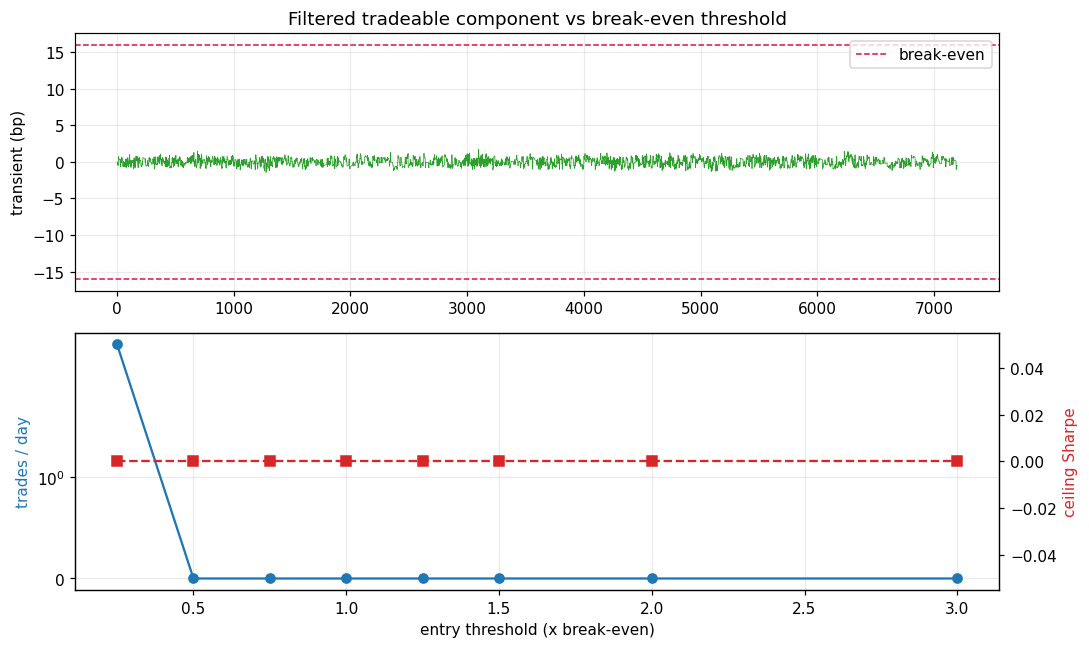

In [11]:
fig, axes = plt.subplots(2, 1, figsize=(10, 6))
sample = slice(0, min(7200, len(transient)))
axes[0].plot(transient[sample], lw=0.5, color="tab:green")
axes[0].axhline(breakeven_bp, color="crimson", ls="--", lw=1, label="break-even")
axes[0].axhline(-breakeven_bp, color="crimson", ls="--", lw=1)
axes[0].set_ylabel("transient (bp)"); axes[0].legend()
axes[0].set_title("Filtered tradeable component vs break-even threshold")

ax1 = axes[1]
ax1.plot(sweep_table.index, sweep_table["trades_per_day"], "o-", color="tab:blue")
ax1.set_yscale("symlog"); ax1.set_xlabel("entry threshold (x break-even)")
ax1.set_ylabel("trades / day", color="tab:blue")
ax2 = ax1.twinx()
ax2.plot(sweep_table.index, sweep_table["sharpe_ceiling"], "s--", color="tab:red")
ax2.set_ylabel("ceiling Sharpe", color="tab:red"); ax2.grid(False)
plt.tight_layout(); plt.show()

## 5. Decision rule

Three conditions, all required:

1. **Kalman half-life lands in 15-60 s.** Outside that range the estimator's own
   bias profile says the number is unreliable.
2. **VR and Kalman agree on the horizon** (ratio within 4x). Disagreement means a
   component swap, and the Kalman fit is discarded.
3. **Break-even sits inside ~2 sigma of the transient sd.** Beyond 3 sigma the
   crossing frequency collapses and no trade count can carry a Sharpe.

If all three hold, the next build is a queue-position model for maker fill
probability — because everything above assumes fills are free, and they are not.
If condition 3 fails at 2 bp but passes at 0 bp, the project is a fee-tier
problem rather than a signal problem, and the effort moves to qualifying for a
rebate tier.